# KF-PLS: Kernel Partial Least-Squares + Kernel Flows
**Dựa trên paper:** *"KF-PLS: Optimizing Kernel Partial Least-Squares (K-PLS) with Kernel Flows"*  
Duma et al., 2023 — [arXiv:2312.06547v1](https://arxiv.org/abs/2312.06547)

---
## Hướng dẫn sử dụng
1. **Cell 1** – Cài thư viện (chỉ chạy lần đầu)  
2. **Cell 2** – Cấu hình: đặt đường dẫn CSV và tên cột target  
3. **Chạy tất cả** (`Run All`) → kết quả R² và RMSE xuất hiện ở cuối

In [ ]:
# ── Cài thư viện (chỉ cần chạy 1 lần) ──────────────────────────────────
# Bỏ dấu # nếu chưa cài
# !pip install numpy pandas scikit-learn matplotlib

---
## ⚙️ Cell 2 – CẤU HÌNH (chỉnh tại đây)

In [124]:
# ════════════════════════════════════════════════════════
#   THAY ĐỔI CÁC THAM SỐ NÀY CHO PHÙ HỢP VỚI DỮ LIỆU
# ════════════════════════════════════════════════════════

CSV_PATH   = "synthetic_data_v2.csv"   # 📂 Đường dẫn tới file CSV
TARGET_COL = "y"          # 🎯 Tên cột biến phụ thuộc (y)
DROP_COLS = ["time"]

# ── Tham số mô hình ───────────────────────────────────
KERNEL     = "gaussian"  # Loại kernel: "gaussian" | "cauchy" | "matern12" | "matern32" | "matern52"
N_LV       = 5           # Số Latent Variables (thử từ 2–10)
TEST_SIZE  = 1e-5         # Tỷ lệ tập test (mặc định 20%)

# ── Tham số Kernel Flows ──────────────────────────────
OPTIMIZE   = False    # True = dùng KF để tối ưu sigma/delta; False = dùng giá trị cố định
N_ITER     = 200     # Số vòng lặp tối ưu (tăng để chính xác hơn, chậm hơn)
N_SUB      = 5       # Số sub-samplings mỗi iteration (tăng = ổn định hơn)
PB         = 0.7     # Tỷ lệ mini-batch (0–1)
PS         = 0.5     # Tỷ lệ sub-batch (0–1)
LR         = 0.1    # Learning rate
MOMENTUM   = 0.9     # Hệ số Polyak momentum

# ── Tham số khởi tạo kernel ───────────────────────────
SIGMA_INIT = 10.0     # σ khởi tạo
DELTA_INIT = 0.1     # δ (regularisation) khởi tạo

print("✅ Cấu hình đã lưu.")

✅ Cấu hình đã lưu.


---
## 📦 Import thư viện

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

print("✅ Import thành công.")

✅ Import thành công.


---
## 1. Kernel Functions (Eq.1–5 trong paper)

In [ ]:
def kernel_gaussian(X1, X2, sigma):
    """Gaussian (RBF) kernel – Eq.(1)"""
    diff = X1[:, None, :] - X2[None, :, :]
    sq_dist = np.sum(diff ** 2, axis=-1)
    return np.exp(-sq_dist / (2 * sigma ** 2))

def kernel_matern12(X1, X2, sigma):
    """Matern 1/2 (Laplacian) kernel – Eq.(2)"""
    diff = X1[:, None, :] - X2[None, :, :]
    dist = np.sqrt(np.sum(diff ** 2, axis=-1) + 1e-12)
    return np.exp(-dist / sigma)

def kernel_matern32(X1, X2, sigma):
    """Matern 3/2 kernel – Eq.(3)"""
    diff = X1[:, None, :] - X2[None, :, :]
    dist = np.sqrt(np.sum(diff ** 2, axis=-1) + 1e-12)
    arg = np.sqrt(3) * dist / sigma
    return (1 + arg) * np.exp(-arg)

def kernel_matern52(X1, X2, sigma):
    """Matern 5/2 kernel – Eq.(4)"""
    diff = X1[:, None, :] - X2[None, :, :]
    dist = np.sqrt(np.sum(diff ** 2, axis=-1) + 1e-12)
    arg = np.sqrt(5) * dist / sigma
    return (1 + arg + arg ** 2 / 3) * np.exp(-arg)

def kernel_cauchy(X1, X2, sigma):
    """Cauchy kernel – Eq.(5)"""
    diff = X1[:, None, :] - X2[None, :, :]
    sq_dist = np.sum(diff ** 2, axis=-1)
    return 1.0 / (1 + sq_dist / sigma ** 2)

KERNELS = {
    "gaussian" : kernel_gaussian,
    "matern12" : kernel_matern12,
    "matern32" : kernel_matern32,
    "matern52" : kernel_matern52,
    "cauchy"   : kernel_cauchy,
}

def build_kernel(X1, X2, sigma, delta, kernel_name="gaussian"):
    """K + δI – Eq.(6)"""
    K = KERNELS[kernel_name](X1, X2, sigma)
    if X1 is X2 or (X1.shape == X2.shape and np.allclose(X1, X2)):
        K += delta * np.eye(len(X1))
    return K

print("✅ Kernel functions đã định nghĩa.")

✅ Kernel functions đã định nghĩa.


---
## 2. SIMPLS Algorithm (Algorithm 1)

In [ ]:
def simpls(X, Y, n_lv):
    """
    SIMPLS – Algorithm 1 từ paper.
    Input : X (n×p kernel matrix), Y (n×q response), n_lv số latent variables
    Output: W, P, Q (loadings)
    """
    n, p = X.shape
    q    = Y.shape[1] if Y.ndim > 1 else 1
    Y2   = Y.reshape(n, q)

    P = np.zeros((p, n_lv))
    W = np.zeros((p, n_lv))
    Q = np.zeros((q, n_lv))

    C = Y2.T @ X   # (q × p) covariance matrix

    for i in range(n_lv):
        _, _, Vt = np.linalg.svd(C, full_matrices=False)
        w  = Vt[0]                       # 1st PC loading
        t  = X @ w                       # X-side scores
        tt = t @ t

        q_vec = (Y2.T @ t) / tt          # Y-side loadings
        p_vec = (X.T  @ t) / tt          # X-side loadings

        W[:, i] = w
        P[:, i] = p_vec
        Q[:, i] = q_vec

        # Deflate covariance matrix
        Pi = P[:, :i+1]
        C  = C - (Pi @ np.linalg.pinv(Pi.T @ Pi) @ Pi.T @ C.T).T

    return W, P, Q

print("✅ SIMPLS đã định nghĩa.")

✅ SIMPLS đã định nghĩa.


---
## 3. K-PLS (Algorithm 2)

In [ ]:
def center_kernel(K):
    """Centre kernel matrix – bước chuẩn hoá K̃"""
    n    = K.shape[0]
    ones = np.ones((n, n)) / n
    return K - ones @ K - K @ ones + ones @ K @ ones

def center_kernel_test(K_test, K_train):
    """Centre test kernel theo training centres – Eq.(8)"""
    col_mean   = K_train.mean(axis=0)
    train_mean = K_train.mean()
    return K_test - K_test.mean(axis=1, keepdims=True) - col_mean + train_mean

def kpls_fit(X_train, Y_train, n_lv, sigma, delta, kernel_name="gaussian"):
    """
    Huấn luyện K-PLS – Algorithm 2.
    Trả về hệ số hồi quy B và kernel matrix.
    """
    n  = X_train.shape[0]
    Y2 = Y_train.reshape(n, -1)

    K   = build_kernel(X_train, X_train, sigma, delta, kernel_name)
    K_c = center_kernel(K)

    W, P, Q = simpls(K_c, Y2, n_lv)

    # B = W (PᵀW)⁻¹ Qᵀ  –  Algorithm 2, bước 4
    B = W @ np.linalg.pinv(P.T @ W) @ Q.T
    return B, K, K_c

print("✅ K-PLS đã định nghĩa.")

✅ K-PLS đã định nghĩa.


---
## 4. Kernel Flows Optimization (Algorithm 3)

In [ ]:
def kf_loss(X_b, Y_b, n_lv, sigma, delta, kernel_name, n_sub, ps):
    """
    Tính loss KF trung bình cho một mini-batch – Eq.(10–13).
    ρ = 1 − norm_s / norm_b,  trung bình qua n_sub lần sub-sampling.
    """
    n_b  = X_b.shape[0]
    Y_b2 = Y_b.reshape(n_b, -1)

    B_b, K_b, K_b_c = kpls_fit(X_b, Y_b2, n_lv, sigma, delta, kernel_name)
    norm_b = float(np.trace(B_b.T @ K_b_c @ B_b))
    if abs(norm_b) < 1e-10:
        return 1.0

    n_s    = max(2, int(ps * n_b))
    losses = []
    for _ in range(n_sub):
        idx = np.random.choice(n_b, n_s, replace=False)
        Xs, Ys = X_b[idx], Y_b2[idx]
        try:
            B_s, _, K_s_c = kpls_fit(Xs, Ys, min(n_lv, n_s - 1), sigma, delta, kernel_name)
            norm_s = float(np.trace(B_s.T @ K_s_c @ B_s))
            losses.append(1 - norm_s / norm_b)
        except Exception:
            losses.append(1.0)

    return float(np.mean(losses))


def kf_gradient(X_b, Y_b, n_lv, sigma, delta, kernel_name, n_sub, ps, eps=1e-4):
    """Gradient số (finite difference) của loss theo [sigma, delta]"""
    base = kf_loss(X_b, Y_b, n_lv, sigma,       delta,       kernel_name, n_sub, ps)
    gs   = kf_loss(X_b, Y_b, n_lv, sigma + eps,  delta,       kernel_name, n_sub, ps)
    gd   = kf_loss(X_b, Y_b, n_lv, sigma,        delta + eps, kernel_name, n_sub, ps)
    return np.array([(gs - base) / eps, (gd - base) / eps]), base


def kernel_flows_optimize(X, Y, n_lv,
                          kernel_name="gaussian",
                          n_iter=200, n_sub=5,
                          pb=0.7, ps=0.5,
                          lr=0.01, momentum=0.9,
                          sigma_init=1.0, delta_init=0.1):
    """
    Kernel Flows – Algorithm 3 với Polyak momentum (Eq.15).
    Trả về (sigma_best, delta_best) và lịch sử loss.
    """
    sigma, delta = sigma_init, delta_init
    v            = np.zeros(2)
    best_loss    = np.inf
    best_params  = (sigma, delta)
    n            = X.shape[0]
    n_b          = max(4, int(pb * n))
    loss_history = []

    print(f"  {'Iter':>6}  {'Loss':>8}  {'σ':>10}  {'δ':>10}")
    print(f"  {'─'*40}")
    for i in range(n_iter):
        idx        = np.random.choice(n, n_b, replace=False)
        X_b, Y_b   = X[idx], Y[idx]
        grad, loss = kf_gradient(X_b, Y_b, n_lv,
                                 max(sigma, 1e-3), max(delta, 1e-6),
                                 kernel_name, n_sub, ps)

        v     = momentum * v + lr * grad
        sigma = max(sigma - v[0], 1e-3)
        delta = max(delta - v[1], 1e-6)

        loss_history.append(loss)

        if loss < best_loss:
            best_loss   = loss
            best_params = (sigma, delta)

        if (i + 1) % max(1, n_iter // 10) == 0 or i == n_iter - 1:
            print(f"  {i+1:>6d}  {loss:>8.4f}  {sigma:>10.4f}  {delta:>10.6f}")

    print(f"\n  ✓ Best → loss={best_loss:.4f}  σ={best_params[0]:.4f}  δ={best_params[1]:.6f}")
    return best_params, loss_history

print("✅ Kernel Flows đã định nghĩa.")

✅ Kernel Flows đã định nghĩa.


---
## 5. Load & Tiền xử lý dữ liệu

In [125]:
df = pd.read_csv(CSV_PATH)

# Kiểm tra cột target
if TARGET_COL not in df.columns:
    raise ValueError(f"❌ Không tìm thấy cột '{TARGET_COL}'.\n"
                     f"   Các cột có trong file: {list(df.columns)}")

X_raw = df.drop(columns=[TARGET_COL] + DROP_COLS).select_dtypes(include=[np.number]).values
y_raw = df[TARGET_COL].values.astype(float)

print(f"📂 File     : {CSV_PATH}")
print(f"📊 Số mẫu  : {X_raw.shape[0]}")
print(f"🔢 Số biến : {X_raw.shape[1]}")
print(f"🎯 Target  : {TARGET_COL}  (min={y_raw.min():.3f}, max={y_raw.max():.3f}, mean={y_raw.mean():.3f})")
print(f"\nCác cột đặc trưng: {list(df.drop(columns=[TARGET_COL] + DROP_COLS).select_dtypes(include=[np.number]).columns)}")

📂 File     : synthetic_data_v2.csv
📊 Số mẫu  : 400
🔢 Số biến : 10
🎯 Target  : y  (min=2607.528, max=3352.947, mean=2944.311)

Các cột đặc trưng: ['x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10']


---
## 6. Train / Test Split & Chuẩn hoá (Section 2.5)

In [ ]:
# Train/Test split 80/20 (Section 2.5)
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y_raw, test_size=TEST_SIZE, random_state=42
)

# Chuẩn hoá zero-mean, unit-variance
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_tr_s  = scaler_X.fit_transform(X_tr)
X_te_s  = scaler_X.transform(X_te)
y_tr_s  = scaler_y.fit_transform(y_tr.reshape(-1, 1)).ravel()
y_te_s  = scaler_y.transform(y_te.reshape(-1, 1)).ravel()

# Đảm bảo n_lv không vượt quá giới hạn
n_lv_eff = min(N_LV, X_tr_s.shape[0] - 1, X_tr_s.shape[1])
if n_lv_eff != N_LV:
    print(f"⚠️  N_LV điều chỉnh từ {N_LV} → {n_lv_eff} (giới hạn dữ liệu)")

print(f"✅ Train: {X_tr_s.shape[0]} mẫu  |  Test: {X_te_s.shape[0]} mẫu")
print(f"✅ Chuẩn hoá xong  |  LVs sử dụng: {n_lv_eff}")

✅ Train: 320 mẫu  |  Test: 80 mẫu
✅ Chuẩn hoá xong  |  LVs sử dụng: 5


---
## 7. Kernel Flows Optimization

In [126]:
if OPTIMIZE:
    print(f"⚙️  Tối ưu kernel [{KERNEL}] với Kernel Flows — {N_ITER} iterations...\n")
    (sigma_opt, delta_opt), loss_hist = kernel_flows_optimize(
        X_tr_s, y_tr_s,
        n_lv        = n_lv_eff,
        kernel_name = KERNEL,
        n_iter      = N_ITER,
        n_sub       = N_SUB,
        pb          = PB,
        ps          = PS,
        lr          = LR,
        momentum    = MOMENTUM,
        sigma_init  = SIGMA_INIT,
        delta_init  = DELTA_INIT,
    )

    # Vẽ loss curve
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(loss_hist, color="#2E75B6", linewidth=0.9, alpha=0.85)
    ax.axhline(min(loss_hist), color="tomato", linestyle="--", linewidth=1,
               label=f"Min loss = {min(loss_hist):.4f}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Loss ρ")
    ax.set_title(f"Kernel Flows Loss — kernel={KERNEL}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    sigma_opt, delta_opt = SIGMA_INIT, DELTA_INIT
    loss_hist = []
    print(f"ℹ️  Bỏ qua tối ưu — dùng tham số cố định: σ={sigma_opt}, δ={delta_opt}")

print(f"\n📌 Tham số kernel cuối: σ = {sigma_opt:.4f}  |  δ = {delta_opt:.6f}")

ℹ️  Bỏ qua tối ưu — dùng tham số cố định: σ=10.0, δ=0.1

📌 Tham số kernel cuối: σ = 10.0000  |  δ = 0.100000


---
## 8. Huấn luyện K-PLS & Dự đoán

In [127]:
# Huấn luyện K-PLS với tham số tối ưu
print("🔨 Huấn luyện K-PLS...")
B, K_train, K_train_c = kpls_fit(X_tr_s, y_tr_s, n_lv_eff, sigma_opt, delta_opt, KERNEL)

# Dự đoán tập test
K_train_raw = KERNELS[KERNEL](X_tr_s, X_tr_s, sigma_opt)
K_test_raw  = KERNELS[KERNEL](X_te_s, X_tr_s, sigma_opt)
K_test_c    = center_kernel_test(K_test_raw, K_train_raw)
y_pred_s    = (K_test_c @ B).ravel()

# Chuyển về scale gốc
y_pred = scaler_y.inverse_transform(y_pred_s.reshape(-1, 1)).ravel()

print("✅ Dự đoán hoàn tất.")

🔨 Huấn luyện K-PLS...
✅ Dự đoán hoàn tất.


---
## 9. Kết quả & Đánh giá


════════════════════════════════════════════════
                 KẾT QUẢ KF-PLS               
════════════════════════════════════════════════
  Kernel              : gaussian
  Latent Variables    : 5
  σ (sigma)           : 10.0000
  δ (delta)           : 0.100000
────────────────────────────────────────────────
  R²                  : 0.3617   (tốt hơn → gần 1)
  RMSE                : 112.8218
  NRMSE               : 15.14%
════════════════════════════════════════════════



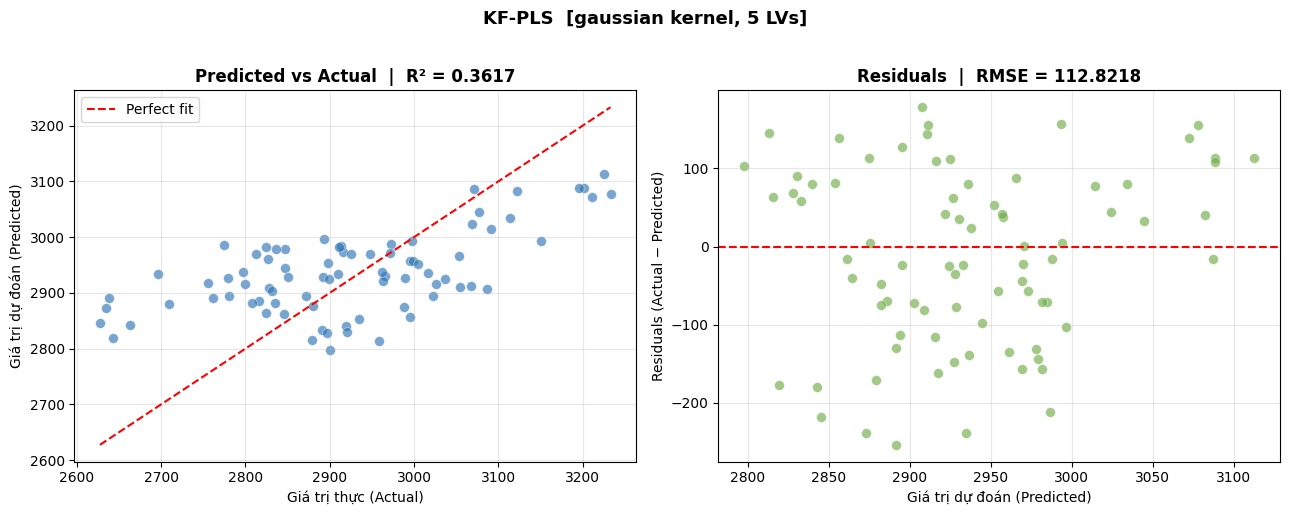

In [128]:
# ── Tính metrics ──────────────────────────────────────────────────────────
r2    = r2_score(y_te, y_pred)
rmse  = np.sqrt(mean_squared_error(y_te, y_pred))
nrmse = rmse / (y_tr.max() - y_tr.min()) * 100

# ── In kết quả ────────────────────────────────────────────────────────────
border = "═" * 48
print(f"\n{border}")
print(f"  {'KẾT QUẢ KF-PLS':^44}")
print(f"{border}")
print(f"  {'Kernel':<20}: {KERNEL}")
print(f"  {'Latent Variables':<20}: {n_lv_eff}")
print(f"  {'σ (sigma)':<20}: {sigma_opt:.4f}")
print(f"  {'δ (delta)':<20}: {delta_opt:.6f}")
print(f"{'─'*48}")
print(f"  {'R²':<20}: {r2:.4f}   {'(tốt hơn → gần 1)':}")
print(f"  {'RMSE':<20}: {rmse:.4f}")
print(f"  {'NRMSE':<20}: {nrmse:.2f}%")
print(f"{border}\n")

# ── Biểu đồ Predicted vs Actual ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scatter plot
ax = axes[0]
ax.scatter(y_te, y_pred, alpha=0.65, color="#2E75B6", edgecolors="white", linewidths=0.4, s=50)
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Giá trị thực (Actual)")
ax.set_ylabel("Giá trị dự đoán (Predicted)")
ax.set_title(f"Predicted vs Actual  |  R² = {r2:.4f}", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3)

# Residuals plot
ax2 = axes[1]
residuals = y_te - y_pred
ax2.scatter(y_pred, residuals, alpha=0.65, color="#70AD47", edgecolors="white", linewidths=0.4, s=50)
ax2.axhline(0, color="red", linestyle="--", linewidth=1.5)
ax2.set_xlabel("Giá trị dự đoán (Predicted)")
ax2.set_ylabel("Residuals (Actual − Predicted)")
ax2.set_title(f"Residuals  |  RMSE = {rmse:.4f}", fontweight="bold")
ax2.grid(True, alpha=0.3)

plt.suptitle(f"KF-PLS  [{KERNEL} kernel, {n_lv_eff} LVs]", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 10. (Tuỳ chọn) So sánh các Kernel

Chạy cell này để so sánh hiệu năng của tất cả kernel functions trên cùng bộ dữ liệu.  
*Lưu ý: mất thêm thời gian vì phải train nhiều lần.*

Kernel              R²        RMSE     NRMSE
─────────────────────────────────────────────
gaussian        0.3617    112.8218    15.14%  ← KF-optimized
matern12        0.7960     63.7812     8.56%
matern32        0.5961     89.7499    12.04%
matern52        0.4897    100.8725    13.53%
cauchy          0.5304     96.7698    12.98%


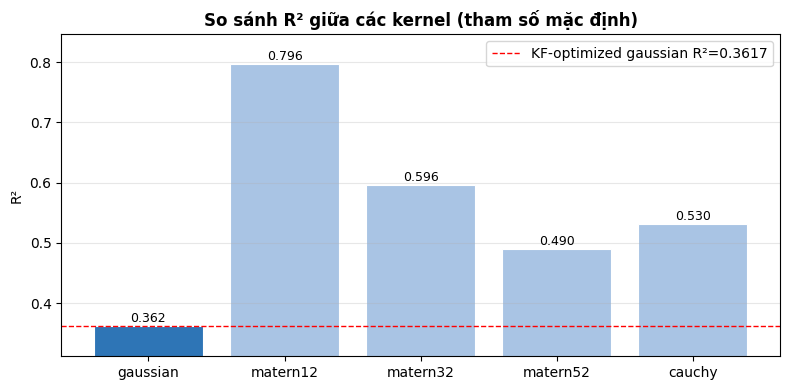

In [129]:
# ── So sánh các kernel (không dùng KF optimize, dùng tham số mặc định) ──
compare_results = {}

print(f"{'Kernel':<12}  {'R²':>8}  {'RMSE':>10}  {'NRMSE':>8}")
print("─" * 45)

for k_name in KERNELS:
    try:
        B_k, K_k, _ = kpls_fit(X_tr_s, y_tr_s, n_lv_eff, SIGMA_INIT, DELTA_INIT, k_name)
        K_tr_raw  = KERNELS[k_name](X_tr_s, X_tr_s, SIGMA_INIT)
        K_te_raw  = KERNELS[k_name](X_te_s, X_tr_s, SIGMA_INIT)
        K_te_c    = center_kernel_test(K_te_raw, K_tr_raw)
        yp_s      = (K_te_c @ B_k).ravel()
        yp        = scaler_y.inverse_transform(yp_s.reshape(-1, 1)).ravel()

        r2_k    = r2_score(y_te, yp)
        rmse_k  = np.sqrt(mean_squared_error(y_te, yp))
        nrmse_k = rmse_k / (y_tr.max() - y_tr.min()) * 100

        compare_results[k_name] = {"R2": r2_k, "RMSE": rmse_k, "NRMSE": nrmse_k}
        marker = "  ← KF-optimized" if k_name == KERNEL else ""
        print(f"{k_name:<12}  {r2_k:>8.4f}  {rmse_k:>10.4f}  {nrmse_k:>7.2f}%{marker}")
    except Exception as e:
        print(f"{k_name:<12}  ERROR: {e}")

# Bar chart
kernels_list = list(compare_results.keys())
r2_vals      = [compare_results[k]["R2"]   for k in kernels_list]
colors       = ["#2E75B6" if k == KERNEL else "#A9C4E4" for k in kernels_list]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(kernels_list, r2_vals, color=colors, edgecolor="white", linewidth=0.8)
ax.set_ylim(max(0, min(r2_vals) - 0.05), min(1.05, max(r2_vals) + 0.05))
ax.set_ylabel("R²")
ax.set_title("So sánh R² giữa các kernel (tham số mặc định)", fontweight="bold")
ax.axhline(r2, color="red", linestyle="--", linewidth=1, label=f"KF-optimized {KERNEL} R²={r2:.4f}")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
for bar, val in zip(bars, r2_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

---
## 11. (Tuỳ chọn) Lưu kết quả dự đoán ra CSV

In [130]:
# Tạo DataFrame kết quả và lưu file
results_df = pd.DataFrame({
    "actual"   : y_te,
    "predicted": y_pred,
    "residual" : y_te - y_pred,
})

output_path = "kfpls_predictions.csv"
results_df.to_csv(output_path, index=False)
print(f"✅ Đã lưu kết quả dự đoán → {output_path}")
print(results_df.describe().round(4))

✅ Đã lưu kết quả dự đoán → kfpls_predictions.csv
          actual  predicted  residual
count    80.0000    80.0000   80.0000
mean   2922.2733  2935.4454  -13.1721
std     142.1042    72.3282  112.7572
min    2627.3824  2797.6945 -253.7354
25%    2827.1890  2884.9477  -98.9131
50%    2912.5221  2928.1998  -15.3998
75%    3007.9890  2978.3417   80.0240
max    3233.1586  3112.6508  178.3284
